# Station-Day Binary Classification Model

**Reads from**: `data/processed/road_station_day_dataset.parquet` (EDA 05)  
**Reads from**: `data/processed/road_timetable_station_day.parquet` (EDA 06, for forward prediction)  
**Output**: `models/road_rail_classification_model.pkl`, `models/road_rail_classification_meta.json`

This notebook trains a supervised binary classifier to predict whether a station will experience a mean arrival delay greater than five minutes on a given day, using road closure features and historical rail performance signals. Multiple models are compared and XGBoost is selected as the primary model based on Precision-Recall AUC, which is the appropriate metric for the class-imbalanced target. The trained model is then applied to the timetable dataset to generate forward-looking disruption predictions.

---
**Sections**
0. Setup and data load  
1. Duration cap  
2. Define binary target  
3. Disruption rate by day of week  
4. Feature set definition  
5. Temporal train/test split  
6. Model definitions  
7. Train and evaluate all models  
8. Model comparison plots  
9. Precision-Recall curves  
10. Confusion matrices (top 2 models)  
11. Optimal threshold selection  
12. Feature importance  
13. Forward prediction on timetable dataset  
14. Predicted disruption by day of week  
15. Save model and metadata  


## 0. Setup and Data Load

In [35]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import os
import json
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time as timer

pd.set_option("display.max_columns", 40)
os.makedirs("figures/classification", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
os.makedirs("./sample_data/processed", exist_ok=True)
os.makedirs("./models", exist_ok=True)
warnings.filterwarnings("ignore", category=UserWarning)
%matplotlib inline

# Day-of-week label map - reused in sections 3 and 14
DOW_MAP = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
station_day_df = pd.read_parquet("./data/processed/road_station_day_dataset.parquet")
station_day_df["planned_date"] = pd.to_datetime(station_day_df["planned_date"])

print(f"Loaded: {len(station_day_df):,} station-day rows")
print(f"Unique stations: {station_day_df['station_name'].nunique():,}")
print(f"Date range: {station_day_df['planned_date'].min().date()} - {station_day_df['planned_date'].max().date()}")
print(f"Columns: {list(station_day_df.columns)}")

Loaded: 33,941 station-day rows
Unique stations: 2,506
Date range: 2026-04-03 - 2026-04-28
Columns: ['station_name', 'loc_stanox', 'planned_date', 'train_movements', 'mean_delay_minutes', 'median_delay_minutes', 'max_delay_minutes', 'late_share', 'delayed_5min_share', 'severe_15min_share', 'peak_movement_share', 'station_disrupted', 'stanox', 'road_closure_count', 'min_distance_km', 'mean_distance_km', 'max_effective_duration_hours', 'mean_effective_duration_hours', 'inv_distance_sum', 'total_closure_severity', 'max_road_class', 'n_unplanned_closures', 'has_road_closure', 'movements_during_closure', 'mean_delay_during_closure', 'pct_late_during_closure', 'max_delay_during_closure', 'pct_delayed_5min_during', 'day_of_week', 'is_weekend', 'is_monday', 'is_friday', 'closures_lag1d', 'closures_lag3d', 'closures_lag7d']


## 1. Duration Cap

`max_effective_duration_hours` contains extreme values (up to 456 hours in some windows). Values are capped at the 99th percentile of training data to prevent multi-week closures from dominating tree splits. The same cap is applied at inference time.

In [37]:
P99_DURATION = station_day_df["max_effective_duration_hours"].quantile(0.99)
station_day_df["max_effective_duration_hours"] = station_day_df[
    "max_effective_duration_hours"
].clip(upper=P99_DURATION)
station_day_df["mean_effective_duration_hours"] = station_day_df[
    "mean_effective_duration_hours"
].clip(upper=P99_DURATION)

print(f"Duration capped at 99th percentile: {P99_DURATION:.1f} hours ({P99_DURATION/24:.1f} days)")
print(station_day_df["max_effective_duration_hours"].describe().round(2))

Duration capped at 99th percentile: 504.0 hours (21.0 days)
count    33941.00
mean       142.03
std        223.26
min          0.00
25%          0.00
50%          0.25
75%        504.00
max        504.00
Name: max_effective_duration_hours, dtype: float64


## 2. Define Binary Target

A station-day is labelled as disrupted (1) when the mean arrival delay across all movements at that station on that day exceeds five minutes. This threshold aligns with the industry definition used by the Office of Rail and Road (2024).

Threshold: mean delay > 5 min
Not disrupted (0): 32,024
Disrupted     (1): 1,917
Disruption rate:   5.65%
Class imbalance ratio (neg/pos): 16.7:1


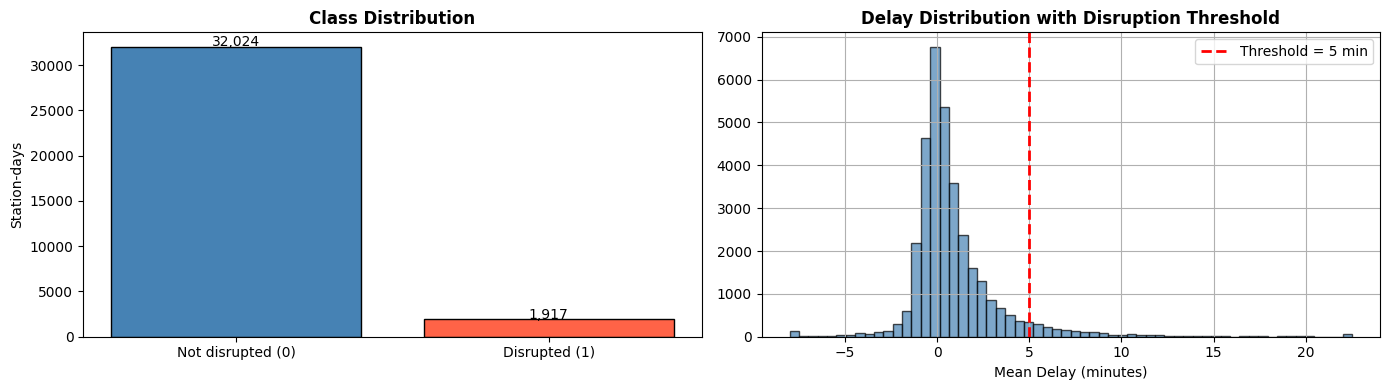

In [38]:
DISRUPTION_THRESHOLD = 5  # minutes, mean station-day delay

station_day_df["disrupted"] = (
    station_day_df["mean_delay_minutes"] > DISRUPTION_THRESHOLD
).astype(int)

counts = station_day_df["disrupted"].value_counts()
rate   = station_day_df["disrupted"].mean()

print(f"Threshold: mean delay > {DISRUPTION_THRESHOLD} min")
print(f"Not disrupted (0): {counts.get(0, 0):,}")
print(f"Disrupted     (1): {counts.get(1, 0):,}")
print(f"Disruption rate:   {rate:.2%}")
print(f"Class imbalance ratio (neg/pos): {counts.get(0,0)/counts.get(1,1):.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(
    ["Not disrupted (0)", "Disrupted (1)"],
    [counts.get(0,0), counts.get(1,0)],
    color=["steelblue", "tomato"], edgecolor="black"
)
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylabel("Station-days")
for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontsize=10)

station_day_df["mean_delay_minutes"].hist(
    bins=60, ax=axes[1], edgecolor="black", alpha=0.7, color="steelblue"
)
axes[1].axvline(DISRUPTION_THRESHOLD, color="red", linestyle="--", lw=2,
                label=f"Threshold = {DISRUPTION_THRESHOLD} min")
axes[1].set_xlabel("Mean Delay (minutes)")
axes[1].set_title("Delay Distribution with Disruption Threshold", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/classification/class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Disruption Rate by Day of Week

Disruption rate by day of week:
     disruption_rate  n_days
Mon            0.056    6322
Tue            0.037    6029
Wed            0.038    1976
Thu            0.047    4276
Fri            0.086    6070
Sat            0.069    3639
Sun            0.052    5629


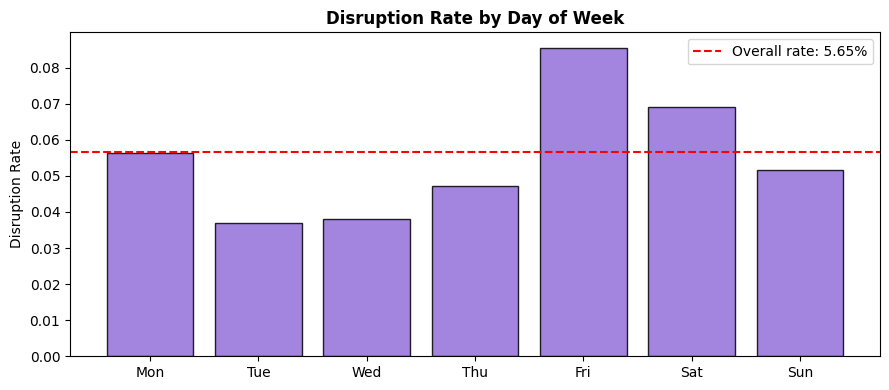

In [39]:
dow_stats = (
    station_day_df.groupby("day_of_week")["disrupted"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "disruption_rate", "count": "n_days"})
)
dow_stats.index = [DOW_MAP[i] for i in dow_stats.index]

print("Disruption rate by day of week:")
print(dow_stats.round(3))

plt.figure(figsize=(9, 4))
plt.bar(dow_stats.index, dow_stats["disruption_rate"],
        color="mediumpurple", edgecolor="black", alpha=0.85)
plt.axhline(rate, color="red", linestyle="--", lw=1.5,
            label=f"Overall rate: {rate:.2%}")
plt.ylabel("Disruption Rate")
plt.title("Disruption Rate by Day of Week", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("figures/classification/disruption_by_dow.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Feature Set Definition

In [40]:
# Full feature set - includes new features from eda_05 
# total_closure_severity, max_road_class, lag features added
# Must match exactly what is present in both training and timetable datasets

BASE_FEATURES = [
    # Closure presence and severity
    "has_road_closure",
    "road_closure_count",
    "n_unplanned_closures",
    "min_distance_km",
    "mean_distance_km",
    "max_effective_duration_hours",
    "mean_effective_duration_hours",
    "inv_distance_sum",
    "total_closure_severity",
    "max_road_class",
    # Lag features - temporal memory of road pressure
    "closures_lag1d",
    "closures_lag3d",
    "closures_lag7d",
    # Temporal context
    "day_of_week",
    "is_weekend",
    "is_monday",
    "is_friday",
    # Service volume
    "train_movements",
]

features = [f for f in BASE_FEATURES if f in station_day_df.columns]
missing  = [f for f in BASE_FEATURES if f not in station_day_df.columns]

if missing:
    print(f"WARNING - features missing from training data (re-run eda_05): {missing}")
else:
    print(f"All {len(features)} features present in training data.")

print(f"\nFeatures used: {features}")

All 18 features present in training data.

Features used: ['has_road_closure', 'road_closure_count', 'n_unplanned_closures', 'min_distance_km', 'mean_distance_km', 'max_effective_duration_hours', 'mean_effective_duration_hours', 'inv_distance_sum', 'total_closure_severity', 'max_road_class', 'closures_lag1d', 'closures_lag3d', 'closures_lag7d', 'day_of_week', 'is_weekend', 'is_monday', 'is_friday', 'train_movements']


## 5. Temporal Train/Test Split

Data is sorted by date and split 80/20. A temporal split prevents future closure information leaking into training via lag features, which would happen with a random split.

In [42]:
TARGET = "disrupted"

df_model = (
    station_day_df[features + [TARGET, "planned_date"]]
    .dropna(subset=features)
    .sort_values("planned_date")
    .reset_index(drop=True)
)

unique_dates = sorted(df_model["planned_date"].dt.date.unique())

# Compute split index on dates, not rows
split_idx = int(len(unique_dates) * 0.8)
cutoff_date = pd.to_datetime(unique_dates[split_idx])

# Split using date boundary
train_df = df_model[df_model["planned_date"] < cutoff_date]
test_df  = df_model[df_model["planned_date"] >= cutoff_date]

X_train = train_df[features]
X_test  = test_df[features]
y_train = train_df[TARGET]
y_test  = test_df[TARGET]

print(f"Train: {len(X_train):,} rows | {train_df['planned_date'].min().date()} - {train_df['planned_date'].max().date()}")
print(f"  Disruption rate: {y_train.mean():.2%}")
print()
print(f"Test:  {len(X_test):,} rows  | {test_df['planned_date'].min().date()} - {test_df['planned_date'].max().date()}")
print(f"  Disruption rate: {y_test.mean():.2%}")

Train: 24,746 rows | 2026-04-03 - 2026-04-23
  Disruption rate: 5.32%

Test:  9,195 rows  | 2026-04-24 - 2026-04-28
  Disruption rate: 6.54%


## 6. Model Definitions

Six models are compared: a majority-class dummy baseline, logistic regression, balanced random forest, histogram-based gradient boosting, XGBoost and LightGBM.

The dummy baseline uses `strategy="most_frequent"`, which always predicts the majority class (not disrupted). Its `predict_proba` returns a constant probability of zero for the positive class, so it plots as a single degenerate point at (recall=0, precision=1) on the PR curve. Its PR-AUC equals the disruption rate and its ROC-AUC is exactly 0.5. It is included only as a lower-bound reference; it is excluded from all post-hoc analyses (confusion matrices, threshold selection, feature importance).

Class imbalance is addressed as follows:
- `LogisticRegression`: `class_weight="balanced"`
- `BalancedRandomForestClassifier`: resamples majority class in each bootstrap
- `HistGradientBoostingClassifier`: `class_weight="balanced"`
- `XGBoost`: `scale_pos_weight` set to the negative/positive training ratio
- `LightGBM`: `class_weight="balanced"` and `is_unbalance=True`

In [43]:
from sklearn.dummy          import DummyClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.ensemble       import HistGradientBoostingClassifier
from sklearn.pipeline       import Pipeline
from sklearn.preprocessing  import StandardScaler
from sklearn.metrics        import (
    f1_score, average_precision_score, roc_auc_score,
    confusion_matrix, classification_report, precision_recall_curve,
)
from xgboost import XGBClassifier

# BalancedRandomForestClassifier from imbalanced-learn resamples the majority
# class within each bootstrap, handling imbalance without needing class_weight.
try:
    from imblearn.ensemble import BalancedRandomForestClassifier
    HAS_IMBL = True
except ImportError:
    HAS_IMBL = False
    print("imbalanced-learn not installed - falling back to RandomForestClassifier "
          "with class_weight='balanced'.")
    from sklearn.ensemble import RandomForestClassifier

# scale_pos_weight for XGBoost: ratio of negative to positive training examples
spw = (
    (y_train == 0).sum() / (y_train == 1).sum()
    if (y_train == 1).sum() > 0 else 1.0
)
print(f"Train class ratio (neg/pos): {spw:.1f}:1  ->  XGBoost scale_pos_weight = {spw:.2f}")

# --- Dummy baseline ---
# strategy="most_frequent" always predicts class 0 (the majority class).
# predict_proba returns P(class=1)=0 for every row, so:
#   - PR-AUC  = disruption rate (the no-skill lower bound for an imbalanced problem)
#   - ROC-AUC = 0.5 (random chance)
# The Dummy is included solely as a lower-bound reference.
# It is excluded from confusion matrices, threshold selection and feature importance.
models = {
    "Dummy (majority-class baseline)": DummyClassifier(
        strategy="most_frequent", random_state=42
    ),
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced", max_iter=1000, random_state=42
        )),
    ]),
    "BalancedRandomForest": (
        BalancedRandomForestClassifier(
            n_estimators=200, sampling_strategy="auto",
            replacement=True, random_state=42, n_jobs=-1
        )
        if HAS_IMBL else
        RandomForestClassifier(
            n_estimators=200, class_weight="balanced",
            random_state=42, n_jobs=-1
        )
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, max_depth=4,
        class_weight="balanced", random_state=42,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw,
        objective="binary:logistic", eval_metric="aucpr",
        random_state=42, verbosity=0,
    ),
}

try:
    from lightgbm import LGBMClassifier
    models["LightGBM"] = LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        class_weight="balanced", is_unbalance=True,
        random_state=42, verbose=-1,
    )
    print("LightGBM available - included.")
except ImportError:
    print("LightGBM not installed - skipped.")

DUMMY_NAME = "Dummy (majority-class baseline)"
print(f"\nModels to evaluate: {list(models.keys())}")
print(f"\nNote: '{DUMMY_NAME}' is a lower-bound reference only.")
print("It is excluded from confusion matrices, threshold selection and feature importance.")

Train class ratio (neg/pos): 17.8:1  ->  XGBoost scale_pos_weight = 17.80
LightGBM available - included.

Models to evaluate: ['Dummy (majority-class baseline)', 'LogisticRegression', 'BalancedRandomForest', 'HistGradientBoosting', 'XGBoost', 'LightGBM']

Note: 'Dummy (majority-class baseline)' is a lower-bound reference only.
It is excluded from confusion matrices, threshold selection and feature importance.


## 7. Train and Evaluate All Models

In [44]:
results = []

for name, model_obj in models.items():
    t0 = timer.time()
    model_obj.fit(X_train, y_train)
    elapsed = timer.time() - t0

    y_pred  = model_obj.predict(X_test)
    # For the dummy model, we know predict_proba returns all zeros for the positive class,
    # so we can directly set the PR-AUC and ROC-AUC without calling the metrics

    if name == DUMMY_NAME:
        pr_auc  = float(y_test.mean())   # no-skill score: equals the positive rate
        roc_auc = 0.5                    # random chance
        y_proba = np.zeros(len(y_test), dtype=float)
    else:
        y_proba = (
            model_obj.predict_proba(X_test)[:, 1]
            if hasattr(model_obj, "predict_proba")
            else y_pred.astype(float)
        )
        pr_auc  = average_precision_score(y_test, y_proba)
        roc_auc = roc_auc_score(y_test, y_proba)

    results.append({
        "model":     name,
        "F1":        f1_score(y_test, y_pred, zero_division=0),
        "PR_AUC":    pr_auc,
        "ROC_AUC":   roc_auc,
        "train_sec": round(elapsed, 2),
        "is_dummy":  (name == DUMMY_NAME),
        "_model":    model_obj,
        "_y_pred":   y_pred,
        "_y_proba":  y_proba,
    })
    print(f"{name:<38} F1={results[-1]['F1']:.3f}  "
          f"PR-AUC={results[-1]['PR_AUC']:.3f}  "
          f"ROC-AUC={results[-1]['ROC_AUC']:.3f}  ({elapsed:.1f}s)")

results_df = (
    pd.DataFrame(results)
    .sort_values("PR_AUC", ascending=False)
    .reset_index(drop=True)
)

no_skill_prauc = float(y_test.mean())
print()
print("=== Model Comparison Table ===")
display(results_df[["model", "F1", "PR_AUC", "ROC_AUC", "train_sec"]])
print(f"\nNo-skill PR-AUC (= positive class rate): {no_skill_prauc:.3f}")
print("This is the lower bound that any useful model must exceed.")
best_real = results_df[~results_df["is_dummy"]].iloc[0]
print(f"Best real model ({best_real['model']}) PR-AUC uplift: "
      f"+{best_real['PR_AUC'] - no_skill_prauc:.3f}")


Dummy (majority-class baseline)        F1=0.000  PR-AUC=0.065  ROC-AUC=0.500  (0.0s)
LogisticRegression                     F1=0.167  PR-AUC=0.109  ROC-AUC=0.667  (0.1s)
BalancedRandomForest                   F1=0.162  PR-AUC=0.102  ROC-AUC=0.636  (1.0s)
HistGradientBoosting                   F1=0.180  PR-AUC=0.115  ROC-AUC=0.668  (0.2s)
XGBoost                                F1=0.187  PR-AUC=0.123  ROC-AUC=0.684  (0.4s)
LightGBM                               F1=0.141  PR-AUC=0.118  ROC-AUC=0.682  (0.2s)

=== Model Comparison Table ===


,model,F1,PR_AUC,ROC_AUC,train_sec
0,XGBoost,0.187354,0.123069,0.683796,0.42
1,LightGBM,0.140683,0.117536,0.681875,0.21
2,HistGradientBoosting,0.179839,0.115346,0.668098,0.25
3,LogisticRegression,0.167103,0.109300,0.666530,0.09
4,BalancedRandomForest,0.161991,0.102241,0.635907,1.01
5,Dummy (majority-class baseline),0.000000,0.065362,0.500000,0.00



No-skill PR-AUC (= positive class rate): 0.065
This is the lower bound that any useful model must exceed.
Best real model (XGBoost) PR-AUC uplift: +0.058


## 8. Model Comparison Plots

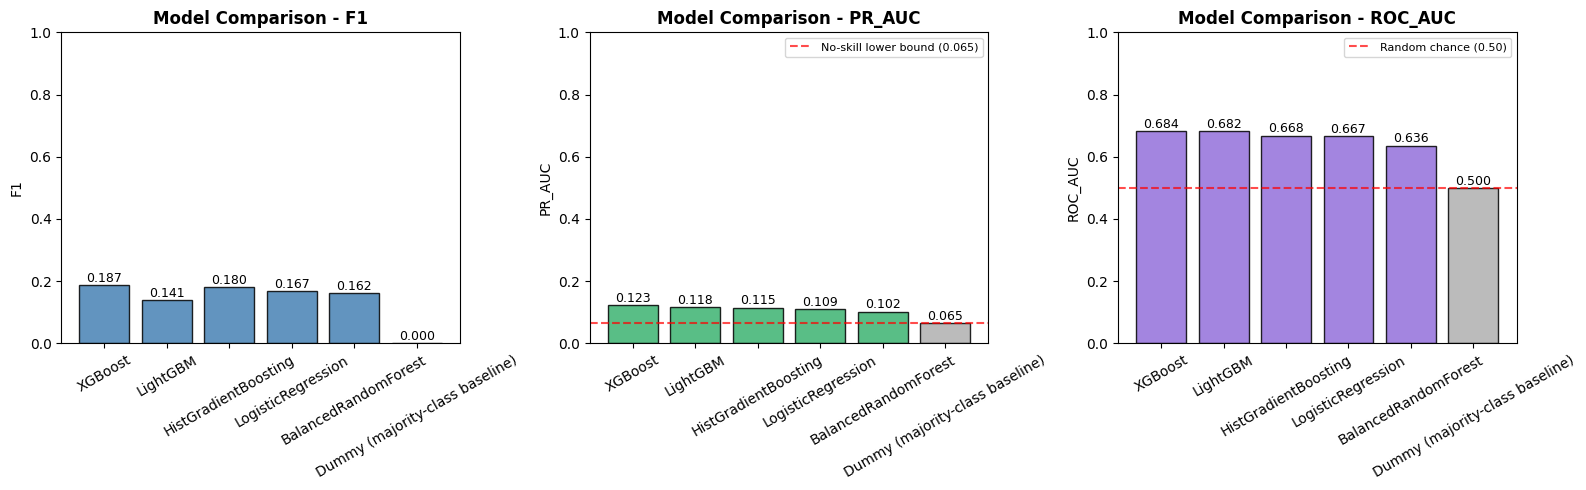

In [45]:
no_skill_prauc = float(y_test.mean())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, color in [
    (axes[0], "F1",      "steelblue"),
    (axes[1], "PR_AUC",  "mediumseagreen"),
    (axes[2], "ROC_AUC", "mediumpurple"),
]:
    bar_colors = [
        "#b0b0b0" if r else color
        for r in results_df["is_dummy"]
    ]
    ax.bar(results_df["model"], results_df[metric],
           color=bar_colors, edgecolor="black", alpha=0.85)
    ax.set_title(f"Model Comparison - {metric}", fontweight="bold")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylim(0, 1)
    for i, v in enumerate(results_df[metric]):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

    if metric == "PR_AUC":
        ax.axhline(no_skill_prauc, color="red", linestyle="--", alpha=0.7,
                   label=f"No-skill lower bound ({no_skill_prauc:.3f})")
        ax.legend(fontsize=8)
    elif metric == "ROC_AUC":
        ax.axhline(0.5, color="red", linestyle="--", alpha=0.7,
                   label="Random chance (0.50)")
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("figures/classification/model_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


## 9. Precision-Recall Curves

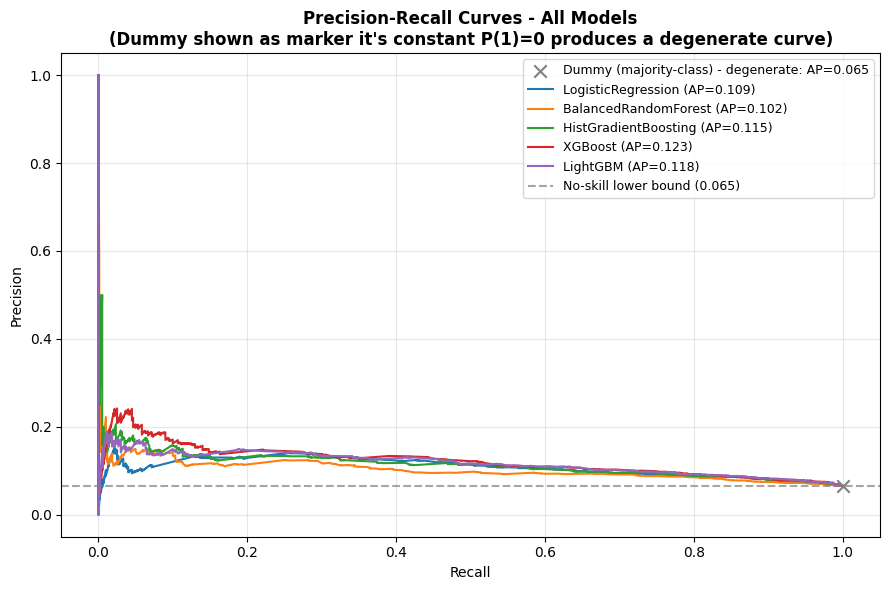

In [46]:
no_skill_prauc = float(y_test.mean())

plt.figure(figsize=(9, 6))

for row in results:
    if row["is_dummy"]:
        plt.scatter([1.0], [no_skill_prauc], marker="x", s=80, zorder=5,
                    color="grey",
                    label=f"Dummy (majority-class) - degenerate: AP={no_skill_prauc:.3f}")
        continue
    p, r, _ = precision_recall_curve(y_test, row["_y_proba"])
    plt.plot(r, p, lw=1.5, label=f"{row['model']} (AP={row['PR_AUC']:.3f})")

plt.axhline(no_skill_prauc, color="grey", linestyle="--", alpha=0.7,
            label=f"No-skill lower bound ({no_skill_prauc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves - All Models\n"
          "(Dummy shown as marker it's constant P(1)=0 produces a degenerate curve)",
          fontweight="bold")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/classification/precision_recall_curves.png", dpi=200, bbox_inches="tight")
plt.show()


## 10. Confusion Matrices (Top 2 Models)


XGBoost:
               precision    recall  f1-score   support

Not disrupted       0.96      0.71      0.81      8594
    Disrupted       0.11      0.53      0.19       601

     accuracy                           0.70      9195
    macro avg       0.53      0.62      0.50      9195
 weighted avg       0.90      0.70      0.77      9195


LightGBM:
               precision    recall  f1-score   support

Not disrupted       0.98      0.19      0.32      8594
    Disrupted       0.08      0.95      0.14       601

     accuracy                           0.24      9195
    macro avg       0.53      0.57      0.23      9195
 weighted avg       0.92      0.24      0.31      9195



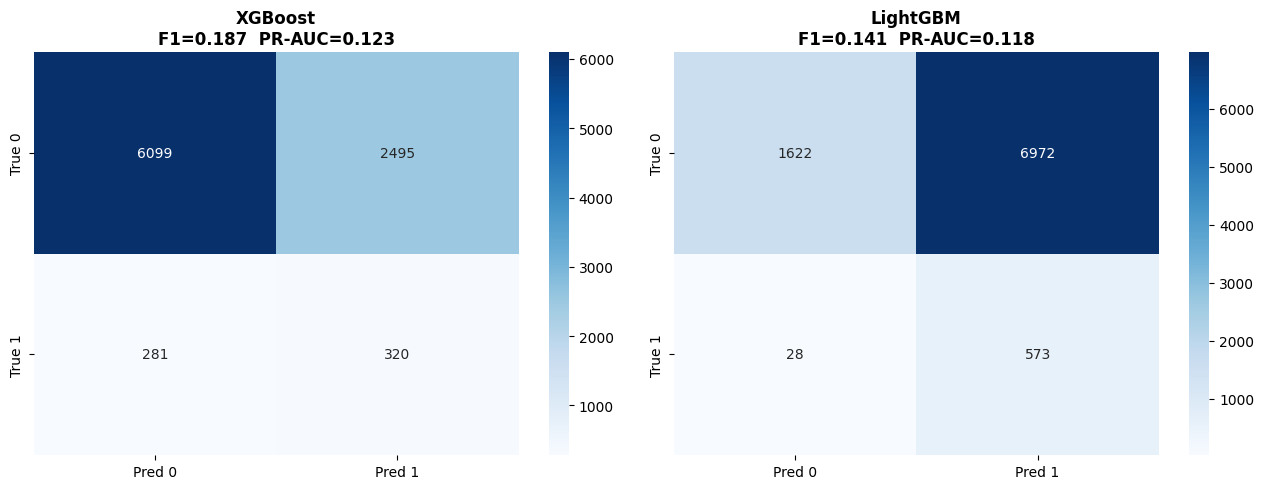

In [47]:
import seaborn as sns

real_results = [r for r in results if not r["is_dummy"]]
top2 = sorted(real_results, key=lambda r: r["PR_AUC"], reverse=True)[:2]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, row in zip(axes, top2):
    cm = confusion_matrix(y_test, row["_y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"])
    ax.set_title(
        f"{row['model']}\nF1={row['F1']:.3f}  PR-AUC={row['PR_AUC']:.3f}",
        fontweight="bold"
    )
    print(f"\n{row['model']}:")
    print(classification_report(
        y_test, row["_y_pred"],
        target_names=["Not disrupted", "Disrupted"],
        zero_division=0
    ))

plt.tight_layout()
plt.savefig("figures/classification/confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()


## 11. Optimal Threshold Selection

The default 0.5 probability threshold is not optimal for imbalanced data. The threshold that maximises F1 on the test set is selected and stored in the model metadata.

Best model: XGBoost  (PR-AUC=0.123, F1=0.187)


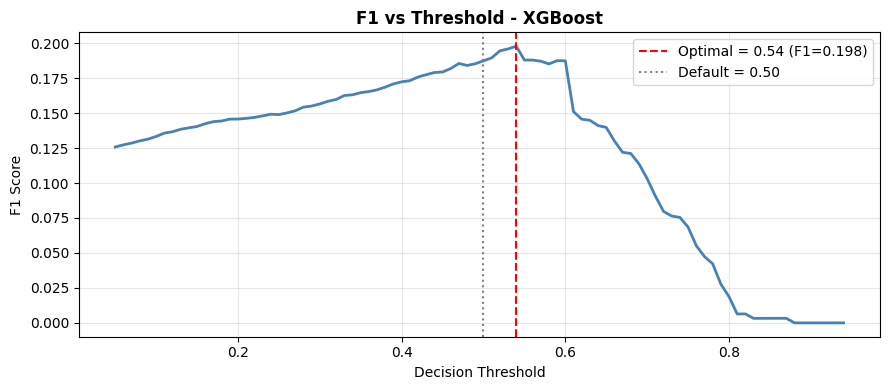


Optimal threshold: 0.54  ->  F1 = 0.198

               precision    recall  f1-score   support

Not disrupted       0.95      0.77      0.85      8594
    Disrupted       0.13      0.47      0.20       601

     accuracy                           0.75      9195
    macro avg       0.54      0.62      0.53      9195
 weighted avg       0.90      0.75      0.81      9195



In [48]:
# Best real model by PR-AUC (dummy already excluded from real_results)
best_row   = sorted(real_results, key=lambda r: r["PR_AUC"], reverse=True)[0]
best_model = best_row["_model"]
best_name  = best_row["model"]
best_proba = best_row["_y_proba"]

print(f"Best model: {best_name}  (PR-AUC={best_row['PR_AUC']:.3f}, F1={best_row['F1']:.3f})")

thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores  = [
    f1_score(y_test, (best_proba >= t).astype(int), zero_division=0)
    for t in thresholds
]

opt_idx = np.argmax(f1_scores)
opt_t   = thresholds[opt_idx]
opt_f1  = f1_scores[opt_idx]

plt.figure(figsize=(9, 4))
plt.plot(thresholds, f1_scores, lw=2, color="steelblue")
plt.axvline(opt_t,  color="red",  linestyle="--",
            label=f"Optimal = {opt_t:.2f} (F1={opt_f1:.3f})")
plt.axvline(0.5,    color="grey", linestyle=":",
            label="Default = 0.50")
plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title(f"F1 vs Threshold - {best_name}", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/classification/threshold_analysis.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nOptimal threshold: {opt_t:.2f}  ->  F1 = {opt_f1:.3f}")
print()
print(classification_report(
    y_test, (best_proba >= opt_t).astype(int),
    target_names=["Not disrupted", "Disrupted"],
    zero_division=0
))


## 12. Feature Importance

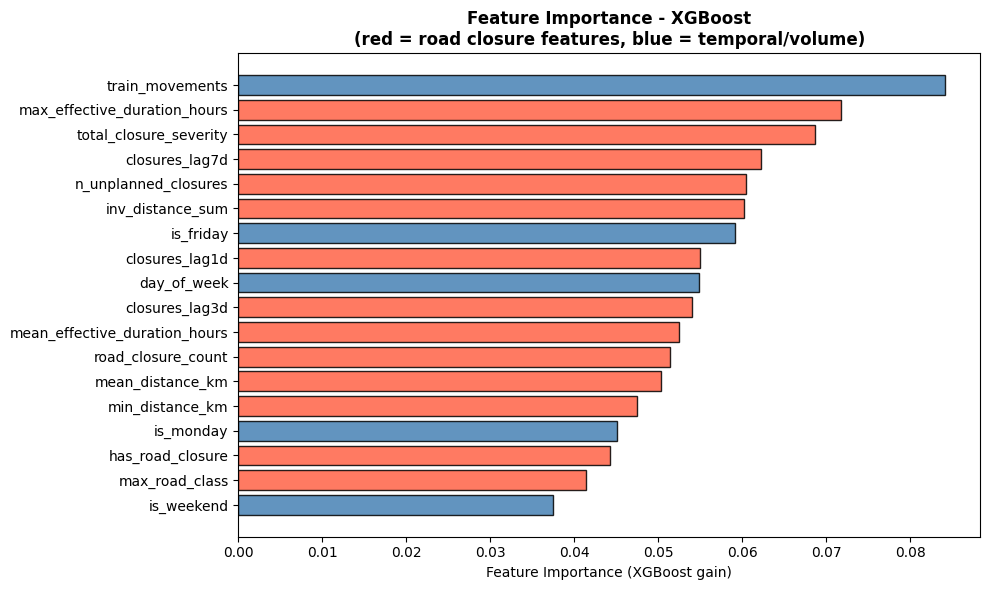

Feature importance ranked:
                      feature  importance
              train_movements    0.084093
 max_effective_duration_hours    0.071795
       total_closure_severity    0.068663
               closures_lag7d    0.062187
         n_unplanned_closures    0.060467
             inv_distance_sum    0.060152
                    is_friday    0.059097
               closures_lag1d    0.054947
                  day_of_week    0.054795
               closures_lag3d    0.054048
mean_effective_duration_hours    0.052472
           road_closure_count    0.051405
             mean_distance_km    0.050277
              min_distance_km    0.047505
                    is_monday    0.045075
             has_road_closure    0.044189
               max_road_class    0.041340
                   is_weekend    0.037493


In [49]:
inner = best_model.named_steps["clf"] if hasattr(best_model, "named_steps") else best_model

if hasattr(inner, "feature_importances_"):
    imp_df = (
        pd.DataFrame({"feature": features, "importance": inner.feature_importances_})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    plt.figure(figsize=(10, 6))
    colors = [
        "tomato" if f in [
            "has_road_closure", "road_closure_count", "n_unplanned_closures",
            "min_distance_km", "mean_distance_km", "max_effective_duration_hours",
            "mean_effective_duration_hours", "inv_distance_sum",
            "total_closure_severity", "max_road_class",
            "closures_lag1d", "closures_lag3d", "closures_lag7d"
        ] else "steelblue"
        for f in imp_df["feature"]
    ]
    plt.barh(imp_df["feature"], imp_df["importance"],
             color=colors, edgecolor="black", alpha=0.85)
    plt.xlabel("Feature Importance (XGBoost gain)")
    plt.title(f"Feature Importance - {best_name}\n(red = road closure features, blue = temporal/volume)",
              fontweight="bold")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("figures/classification/feature_importance.png", dpi=200, bbox_inches="tight")
    plt.show()

    print("Feature importance ranked:")
    print(imp_df.to_string(index=False))

elif hasattr(inner, "coef_"):
    imp_df = (
        pd.DataFrame({"feature": features, "coefficient": inner.coef_.flatten()})
        .sort_values("coefficient", key=abs, ascending=False)
    )
    plt.figure(figsize=(10, 6))
    plt.barh(imp_df["feature"], imp_df["coefficient"],
             color="coolwarm", edgecolor="black")
    plt.title(f"Feature Coefficients - {best_name}", fontweight="bold")
    plt.axvline(0, color="black", lw=0.8)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("figures/classification/feature_importance.png", dpi=200, bbox_inches="tight")
    plt.show()
    display(imp_df)

## 13. Forward Prediction on Timetable Dataset

Apply the best classifier to the timetable dataset from EDA 06. The same duration cap applied during training is re-applied here to ensure feature distributions at inference time match those seen during training.

In [50]:
timetable_day_df = pd.read_parquet(
    "./data/processed/road_timetable_station_day.parquet"
)
timetable_day_df["planned_date"] = pd.to_datetime(timetable_day_df["planned_date"])

# Apply same duration cap as training data
timetable_day_df["max_effective_duration_hours"] = timetable_day_df[
    "max_effective_duration_hours"
].clip(upper=P99_DURATION)
timetable_day_df["mean_effective_duration_hours"] = timetable_day_df[
    "mean_effective_duration_hours"
].clip(upper=P99_DURATION)

# Feature alignment check
missing_inf = [f for f in features if f not in timetable_day_df.columns]
if missing_inf:
    print(f"WARNING - features missing from timetable dataset: {missing_inf}")
    print("Re-run eda_06 to regenerate road_timetable_station_day.parquet")
else:
    print(f"All {len(features)} features present in timetable dataset.")

print(f"Inference dataset: {len(timetable_day_df):,} rows")
print(f"Date range: {timetable_day_df['planned_date'].min().date()} - {timetable_day_df['planned_date'].max().date()}")

X_future = timetable_day_df[features].fillna(0)

# Score
timetable_day_df["disruption_probability"] = best_model.predict_proba(X_future)[:, 1]
timetable_day_df["disrupted_predicted"]    = (
    timetable_day_df["disruption_probability"] >= opt_t
).astype(int)

def assign_risk_band(p):
    if p < 0.30: return "Low"
    if p < 0.50: return "Moderate"
    if p < 0.70: return "High"
    return "Critical"

timetable_day_df["risk_band"] = (
    timetable_day_df["disruption_probability"].apply(assign_risk_band)
)

print(f"\nPrediction summary (threshold = {opt_t:.2f}):")
print(timetable_day_df["disrupted_predicted"].value_counts()
      .rename(index={0: "Not disrupted", 1: "Disrupted"}))

print(f"\nRisk band breakdown:")
print(timetable_day_df["risk_band"].value_counts())

# Top at-risk station-days
id_cols   = [c for c in ["planned_date", "station_name", "station_code"] if c in timetable_day_df.columns]
show_cols = id_cols + [
    "disruption_probability", "risk_band",
    "has_road_closure", "road_closure_count", "min_distance_km", "n_unplanned_closures"
]
show_cols = [c for c in show_cols if c in timetable_day_df.columns]

print("\nTop 20 highest-risk station-days:")
display(
    timetable_day_df
    .sort_values("disruption_probability", ascending=False)
    .head(20)[show_cols]
    .reset_index(drop=True)
)

All 18 features present in timetable dataset.
Inference dataset: 51,437 rows
Date range: 2026-04-09 - 2026-04-30

Prediction summary (threshold = 0.54):
disrupted_predicted
Not disrupted    49113
Disrupted         2324
Name: count, dtype: int64

Risk band breakdown:
risk_band
Low         42008
Moderate     6356
High         2926
Critical      147
Name: count, dtype: int64

Top 20 highest-risk station-days:


,planned_date,station_name,station_code,disruption_probability,risk_band,has_road_closure,road_closure_count,min_distance_km,n_unplanned_closures
0,2026-04-17,Sudbury Hill Harrow,SDH,0.873289,Critical,1.0,14.0,15.449239,14.0
1,2026-04-18,Northolt Park,NLT,0.826555,Critical,1.0,11.0,11.950340,11.0
2,2026-04-13,Sudbury and Harrow Road,SUD,0.814734,Critical,1.0,11.0,13.597877,7.0
3,2026-04-14,Sankey For Penketh,SNK,0.809569,Critical,1.0,11.0,10.019454,5.0
4,2026-04-16,Ruabon,RUA,0.807003,Critical,0.0,0.0,0.000000,0.0
5,2026-04-24,Clifton (Manchester),CLI,0.803855,Critical,1.0,14.0,11.501667,6.0
6,2026-04-26,Entwistle,ENT,0.802273,Critical,1.0,10.0,13.178704,6.0
7,2026-04-17,Clifton (Manchester),CLI,0.800386,Critical,1.0,13.0,10.333799,5.0
8,2026-04-23,South Elmsall,SES,0.793082,Critical,1.0,10.0,12.978527,10.0
9,2026-04-16,Clifton (Manchester),CLI,0.788844,Critical,1.0,12.0,11.466571,4.0


## 14. Predicted Disruption by Day of Week

Predicted disruption rate by day of week (timetable):
     predicted_disruption_rate  n_rows
Mon                      0.019    7512
Tue                      0.007    7522
Wed                      0.008    7518
Thu                      0.176    6780
Fri                      0.023    7494
Sat                      0.035    7499
Sun                      0.063    7112


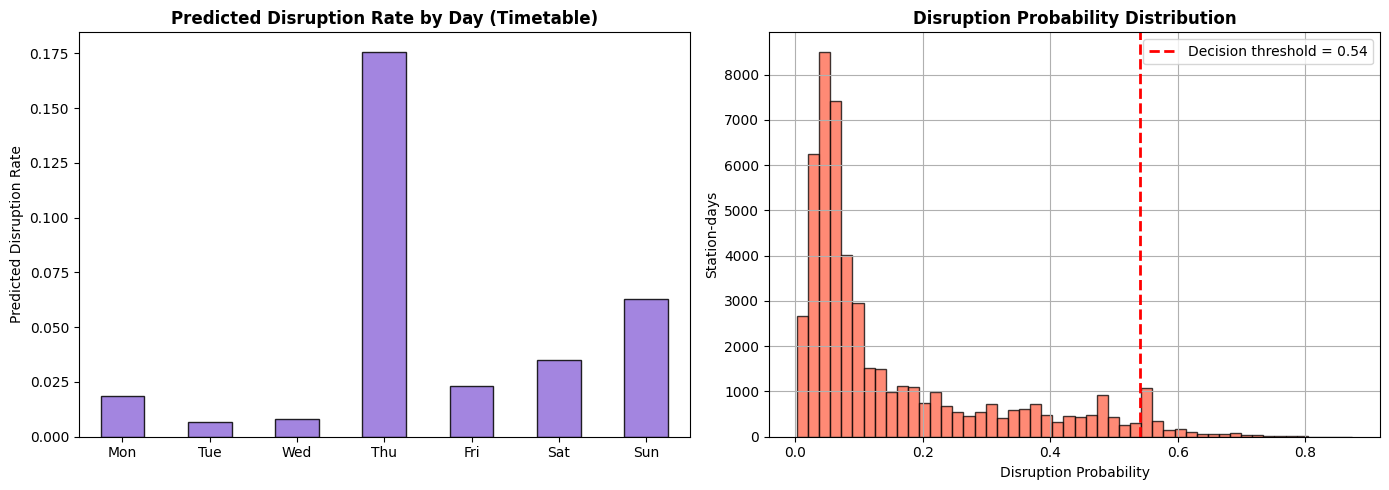

In [51]:
dow_pred = (
    timetable_day_df.groupby("day_of_week")["disrupted_predicted"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "predicted_disruption_rate", "count": "n_rows"})
)
dow_pred.index = [DOW_MAP[i] for i in dow_pred.index]

print("Predicted disruption rate by day of week (timetable):")
print(dow_pred.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dow_pred["predicted_disruption_rate"].plot(
    kind="bar", ax=axes[0], color="mediumpurple",
    edgecolor="black", alpha=0.85
)
axes[0].set_title("Predicted Disruption Rate by Day (Timetable)", fontweight="bold")
axes[0].set_ylabel("Predicted Disruption Rate")
axes[0].tick_params(axis="x", rotation=0)

timetable_day_df["disruption_probability"].hist(
    bins=50, ax=axes[1], color="tomato", edgecolor="black", alpha=0.75
)
axes[1].axvline(opt_t, color="red", linestyle="--", lw=2,
                label=f"Decision threshold = {opt_t:.2f}")
axes[1].set_xlabel("Disruption Probability")
axes[1].set_ylabel("Station-days")
axes[1].set_title("Disruption Probability Distribution", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/classification/timetable_predictions.png", dpi=200, bbox_inches="tight")
plt.show()

## 15. Save Model and Metadata

In [52]:
model_path = "models/road_rail_classification_model.pkl"
meta_path  = "models/road_rail_classification_meta.json"

meta = {
    "model_name":               best_name,
    "features":                 features,
    "target":                   TARGET,
    "disruption_threshold_min": DISRUPTION_THRESHOLD,
    "duration_cap_hours":       float(P99_DURATION),
    "optimal_threshold":        float(opt_t),
    "f1":                       float(opt_f1),
    "pr_auc":                   float(best_row["PR_AUC"]),
    "roc_auc":                  float(best_row["ROC_AUC"]),
    "train_rows":               int(len(X_train)),
    "test_rows":                int(len(X_test)),
    "train_disruption_rate":    float(y_train.mean()),
    "test_disruption_rate":     float(y_test.mean()),
}

joblib.dump({"pipeline": best_model, "meta": meta}, model_path)

with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print(f"Saved model: {model_path}")
print(f"Saved meta:  {meta_path}")
print(json.dumps({k: v for k, v in meta.items() if k != 'features'}, indent=2))

# Save timetable with classifier predictions - regression model reads this next
pred_path = "./data/processed/road_timetable_station_day.parquet"
sample_pred_path = "./sample_data/processed/road_timetable_station_day.csv"
timetable_day_df.to_parquet(pred_path, index=False)
timetable_day_df.to_csv(sample_pred_path, index=False)
print(f"\nSaved predictions: {pred_path}")
print("Columns added: disruption_probability, disrupted_predicted, risk_band")
print("Next step: run regression_model.ipynb to add predicted_delay_minutes")

Saved model: models/road_rail_classification_model.pkl
Saved meta:  models/road_rail_classification_meta.json
{
  "model_name": "XGBoost",
  "target": "disrupted",
  "disruption_threshold_min": 5,
  "duration_cap_hours": 503.9997222222222,
  "optimal_threshold": 0.5400000000000001,
  "f1": 0.1978176698345653,
  "pr_auc": 0.12306909835042792,
  "roc_auc": 0.683795566848674,
  "train_rows": 24746,
  "test_rows": 9195,
  "train_disruption_rate": 0.05318031196961125,
  "test_disruption_rate": 0.0653616095704187
}

Saved predictions: ./data/processed/road_timetable_station_day.parquet
Columns added: disruption_probability, disrupted_predicted, risk_band
Next step: run regression_model.ipynb to add predicted_delay_minutes
